In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\tanaa\Downloads\health_dataset.csv")
df.head()

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,1,18-25,22,55,Male,North,Non-Smoker,Daily,21.5,118,False,False,170,90,10/1/2024
1,2,26-35,30,70,Female,South,Smoker,Weekly,25.2,130,True,True,210,140,12/1/2024
2,3,36-45,40,80,Male,East,Former Smoker,Rarely,27.8,140,True,True,220,150,15/01/2024
3,4,46-60,50,85,Female,West,Non-Smoker,Never,29.5,150,True,True,240,160,18/01/2024
4,5,60+,65,75,Male,North,Smoker,Rarely,26.0,135,True,True,230,145,20/01/2024


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   record_id           50 non-null     int64  
 1   age_group           50 non-null     str    
 2   age                 50 non-null     int64  
 3   weight              50 non-null     int64  
 4   gender              50 non-null     str    
 5   region              50 non-null     str    
 6   smoking_status      50 non-null     str    
 7   exercise_frequency  50 non-null     str    
 8   bmi                 50 non-null     float64
 9   blood_pressure      50 non-null     int64  
 10  diabetes            50 non-null     bool   
 11  hypertension        50 non-null     bool   
 12  cholesterol_level   50 non-null     int64  
 13  glucose_level       50 non-null     int64  
 14  visit_date          50 non-null     str    
dtypes: bool(2), float64(1), int64(6), str(6)
memory usage: 5.3 KB


In [5]:
df.describe()

,record_id,age,weight,bmi,blood_pressure,cholesterol_level,glucose_level
count,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,43.560000,74.700000,26.218000,135.220000,214.700000,133.080000
std,14.57738,17.144238,10.508014,2.714037,12.519845,24.197529,24.478095
min,1.00000,20.000000,53.000000,20.900000,110.000000,165.000000,87.000000
25%,13.25000,28.250000,68.250000,24.725000,128.250000,200.500000,111.250000
50%,25.50000,40.500000,76.500000,26.550000,137.000000,220.500000,141.500000
75%,37.75000,56.750000,82.750000,28.425000,144.750000,231.750000,149.750000
max,50.00000,74.000000,91.000000,30.500000,155.000000,249.000000,166.000000


In [6]:
# Confidence Interval for age
mean = df['age'].mean()
std = df['age'].std()
n = len(df)

ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=std/np.sqrt(n))
ci

(np.float64(38.68766145926947), np.float64(48.432338540730534))

In [7]:
# T-test (Smoker vs Non-Smoker glucose levels)
smoker = df[df['smoking_status']=='Smoker']['glucose_level']
non_smoker = df[df['smoking_status']=='Non-Smoker']['glucose_level']

stats.ttest_ind(smoker, non_smoker)

TtestResult(statistic=np.float64(2.126779437887781), pvalue=np.float64(0.03999067567027398), df=np.float64(38.0))

In [8]:
# Chi-square test
contingency = pd.crosstab(df['smoking_status'], df['diabetes'])
stats.chi2_contingency(contingency)

Chi2ContingencyResult(statistic=np.float64(9.325396825396826), pvalue=np.float64(0.009440952413074235), dof=2, expected_freq=array([[ 2.8,  7.2],
       [ 5.6, 14.4],
       [ 5.6, 14.4]]))

In [9]:
# ANOVA for age groups vs glucose
groups = [group['glucose_level'].values for name, group in df.groupby('age_group')]
stats.f_oneway(*groups)

F_onewayResult(statistic=np.float64(94.13459575011179), pvalue=np.float64(2.901945475313293e-21))

In [10]:
# Correlation
df[['age','bmi']].corr()

,age,bmi
age,1.000000,0.671234
bmi,0.671234,1.000000


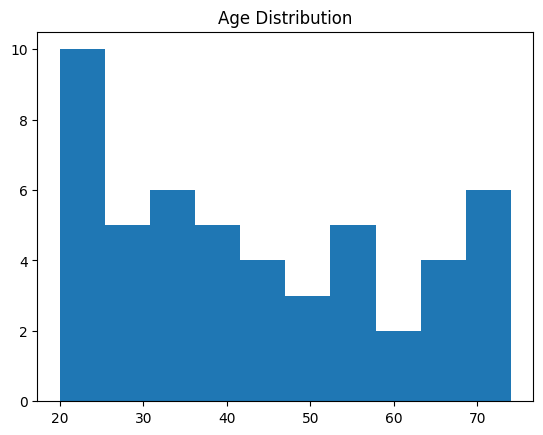

In [11]:
# Plot
plt.hist(df['age'])
plt.title("Age Distribution")
plt.show()